testing scraping one hansard transcript, then putting it into a wordcloud (with the help of claude)

In [26]:
import requests
import bs4 as BeautifulSoup

url = "https://www.ola.org/en/legislative-business/house-documents/parliament-44/session-1/2026-05-25/hansard"

response = requests.get(url)
soup = BeautifulSoup.BeautifulSoup(response.text, "html.parser")

In [27]:
import re
cleaned = re.sub(r"[^a-zA-Z\s]", "", soup.get_text())
print(cleaned[:500])























Hansard Transcript May  Legislative Assembly of Ontario



















Skip to main content





















Legislative Assembly of Ontario


Legislative Assembly of Ontario












              Query
            






Search entire site
Search entire site


























Search entire site
Search entire site




























 Franais











              Query
            






Search entire site
Search entire site




















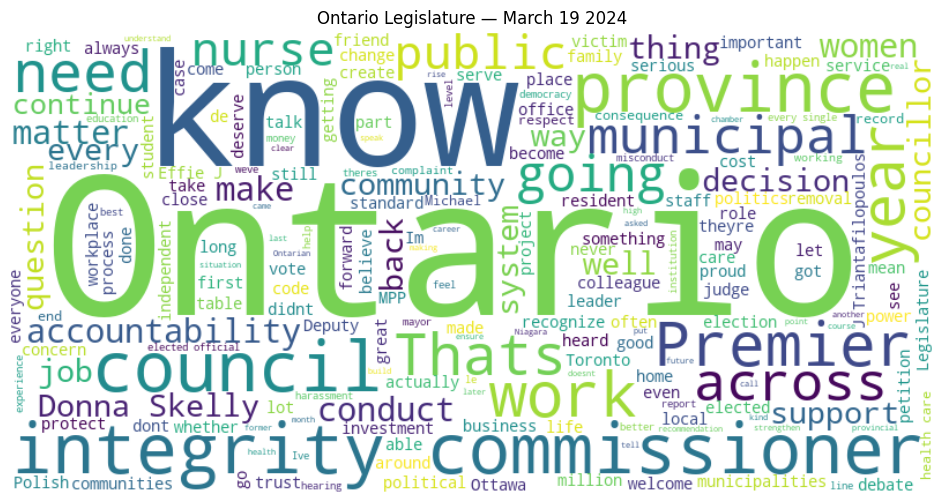

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#stopwords copied directly from openparliament.ca
STOPWORDS = frozenset(["i", "me", "my", "myself", "we", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself",
    "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these",
    "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has",
    "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if",
    "or", "because", "as", "until", "while", "of", "at", "by", "for", "with", "about",
    "against", "between", "into", "through", "during", "before", "after", "above",
    "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under",
    "again", "further", "then", "once", "here", "there", "when", "where", "why", "how",
    "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no",
    "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can",
    "will", "just", "don", "should", "now", # this is the nltk stopwords list
    "it's", "we're", "we'll", "they're", "can't", "won't", "isn't", "don't", "he's",
    "she's", "i'm", "aren't", "government", "house", 'committee', 'would', 'speaker',
    'motion', 'mr', 'mrs', 'ms', 'member', 'minister', 'canada', 'members', 'time',
    'prime', 'one', 'parliament', 'us', 'bill', 'act', 'like', 'canadians', 'people',
    'said', 'want', 'could', 'issue', 'today', 'hon', 'order', 'party', 'canadian',
    'think', 'also', 'new', 'get', 'many', 'say', 'look', 'country', 'legislation',
    'law', 'department', 'two', 'day', 'days', 'madam', 'must', "that's", "okay",
    "thank", "really", "much", "there's", 'yes', 'no'
])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=STOPWORDS
).generate(cleaned)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Ontario Legislature — March 19 2024")
plt.show()
